# **Speaker Identification**

## Import Neccessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from IPython.display import Audio, display
import IPython.display as ipd
import os
import io
import gc
from pathlib import Path
import random
import soundfile as sf
from tqdm import tqdm
import shutil
from glob import glob
from PIL import Image
from datasets import load_dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

%matplotlib inline

#Install torchcodec
!pip install torchcodec --upgrade

In [28]:
#from google.colab import drive
#drive.mount('/content/drive')


## Read in the dataset

In [5]:
# Base directory where .flac files are stored

BASE_DIR = Path(r"C:\Users\niade\Desktop\FYP\data\librispeech_asr\train-clean-100\train-clean-100")

# Recursively list all .flac files
audio_files = list(BASE_DIR.rglob("*.flac"))

print(f"✅ Total audio samples found: {len(audio_files)}")
print("Example files:", audio_files[:5])


✅ Total audio samples found: 28539
Example files: [WindowsPath('C:/Users/niade/Desktop/FYP/data/librispeech_asr/train-clean-100/train-clean-100/911/128684/911-128684-0000.flac'), WindowsPath('C:/Users/niade/Desktop/FYP/data/librispeech_asr/train-clean-100/train-clean-100/911/128684/911-128684-0001.flac'), WindowsPath('C:/Users/niade/Desktop/FYP/data/librispeech_asr/train-clean-100/train-clean-100/911/128684/911-128684-0002.flac'), WindowsPath('C:/Users/niade/Desktop/FYP/data/librispeech_asr/train-clean-100/train-clean-100/911/128684/911-128684-0003.flac'), WindowsPath('C:/Users/niade/Desktop/FYP/data/librispeech_asr/train-clean-100/train-clean-100/911/128684/911-128684-0004.flac')]


In [6]:
# Parse metadata from filenames
data = []
for f in audio_files:
    parts = f.stem.split("-")
    speaker_id, chapter_id, utterance_id = parts
    data.append({
        "file_path": str(f),
        "speaker_id": int(speaker_id),
        "chapter_id": int(chapter_id),
        "utterance_id": int(utterance_id)
    })

df = pd.DataFrame(data)

# Generate 'id' column following LibriSpeech’s schema
df['id'] = df.apply(lambda row: f"{row['speaker_id']}-{row['chapter_id']}-{row['utterance_id']:04d}", axis=1)

# Drop utterance_id (in place) and reorder columns
df.drop('utterance_id', axis=1, inplace=True)
df = df[['id', 'file_path', 'speaker_id', 'chapter_id']]

print('Dataset Shape:', df.shape)
df.head()


Dataset Shape: (28539, 4)


,id,file_path,speaker_id,chapter_id
0,911-128684-0000,C:\Users\niade\Desktop\FYP\data\librispeech_as...,911,128684
1,911-128684-0001,C:\Users\niade\Desktop\FYP\data\librispeech_as...,911,128684
2,911-128684-0002,C:\Users\niade\Desktop\FYP\data\librispeech_as...,911,128684
3,911-128684-0003,C:\Users\niade\Desktop\FYP\data\librispeech_as...,911,128684
4,911-128684-0004,C:\Users\niade\Desktop\FYP\data\librispeech_as...,911,128684


The dataset contains 28539 samples and 4 features

###  **Feature Description**

| **Feature** | **Description** |
|--------------|-----------------|
| **id** | Unique identifier for each sample, formatted as `<speaker_id>-<chapter_id>-<utterance_number>`. Ensures every audio clip is distinctly traceable. |
| **file_path** | Absolute path to the audio file (`.flac` format). Each file contains a single spoken utterance by a specific speaker. |
| **speaker_id** | Unique numerical ID assigned to each speaker. Used as the **class label** for speaker identification. |
| **chapter_id** | Numerical ID representing the audiobook chapter from which the utterance was extracted. Helps organize utterances by context within a speaker. |


---

#  **Exploratory Data Analysis**

### Play a few audio recordings from the dataset


In [7]:
# import random

# Pick a few random samples
samples = df.sample(3, random_state=42)

for _, row in samples.iterrows():
    print(f"\n🎤 Speaker ID: {row['speaker_id']} | Chapter ID: {row['chapter_id']} | ID: {row['id']}")
    display(Audio(filename=row['file_path']))



🎤 Speaker ID: 6529 | Chapter ID: 62554 | ID: 6529-62554-0042



🎤 Speaker ID: 4160 | Chapter ID: 11549 | ID: 4160-11549-0001



🎤 Speaker ID: 5339 | Chapter ID: 14134 | ID: 5339-14134-0036


In [8]:
# Observe Data Better Using a Feature Summary Table
observe_data = pd.DataFrame(columns = ['variable', 'NaN', 'unique', 'nunique', 'dtype'])

for i, col in enumerate(df.columns):
    observe_data.loc[i] = [col, df[col].isna().sum(), df[col].unique(), df[col].nunique(), df[col].dtypes]

observe_data

,variable,NaN,unique,nunique,dtype
0,id,0,"[911-128684-0000, 911-128684-0001, 911-128684-...",28539,object
1,file_path,0,[C:\Users\niade\Desktop\FYP\data\librispeech_a...,28539,object
2,speaker_id,0,"[911, 909, 8975, 89, 887, 8838, 8797, 8770, 87...",251,int64
3,chapter_id,0,"[128684, 130578, 131041, 131044, 131045, 27078...",585,int64


### **Dataset Summary Insight**

| **Aspect** | **Interpretation** |
|-------------|-------------------|
| **Total samples (`id`)** | There are **28,539 unique audio samples**, each represented by a distinct `id` in the format `<speaker_id>-<chapter_id>-<utterance_id>`. This confirms the dataset covers a large and diverse set of utterances. |
| **File paths (`file_path`)** | All 28,539 records have valid `.flac` file paths stored under `/content/drive/MyDrive/.../train-clean-100`. This ensures no missing or corrupt entries — the dataset is complete and accessible for feature extraction. |
| **Speakers (`speaker_id`)** | The dataset includes **251 unique speakers**, each identified by a unique numerical ID. This provides a rich multi-class classification setup for **speaker identification**, where the model must learn voice characteristics across 251 individuals. |
| **Chapters (`chapter_id`)** | There are **585 unique chapters**, indicating that speakers contributed utterances across multiple audiobook contexts. This variety improves robustness by exposing the model to different recording conditions, background noises, and prosody styles. |
| **Missing values (`NaN`)** | All columns have **0 missing entries**, confirming data integrity. |
| **Data types (`dtype`)** | - `id` and `file_path` are strings (`object` dtype).  <br> - `speaker_id` and `chapter_id` are integers (`int64`). |

---

### **Key Takeaways**
- The dataset is **complete, structured, and balanced enough** for supervised learning tasks.  
- With **251 speakers** and **28k+ samples**, it provides sufficient data to train and evaluate a CNN-based speaker identification model.  
- The presence of **multiple chapters per speaker** introduces natural variation, enhancing model generalization across different speaking contexts.


---

## 🎧 **Spectrogram Feature Extraction**

In this section, we transform the raw audio waveforms into **Mel-spectrogram representations** — a 2D time-frequency form that visually and numerically captures the energy distribution of sound across frequencies over time.  

Each audio file in the dataset is converted into a spectrogram image using **Librosa’s Mel-spectrogram function**, which maps frequency to the Mel scale — a perceptually meaningful representation aligned with how humans hear sound.  

This transformation serves two primary purposes:
1. **Feature Engineering:** It converts variable-length audio signals into fixed-size matrices suitable for deep learning models like CNNs.
2. **Data Exploration:** It enables visual inspection of speech patterns, helping us understand differences across speakers and utterances.


The extracted spectrograms will form the **core input features** for our speaker identification model.


In [10]:
# ========== CONFIG ==========
# Use raw string (r prefix) or double backslashes or forward slashes to avoid escape character issues
SPEC_DIR = r"C:\Users\niade\Desktop\FYP\data\spectrograms"
os.makedirs(SPEC_DIR, exist_ok=True)

In [11]:
BATCH_SIZE = 5000  # number of files per batch
SR = 16000         # sample rate for Mel-spectrogram

# ========== FUNCTIONS ==========

def generate_mel_spectrogram(audio_path, sr=SR, n_mels=128, hop_length=512, n_fft=2048):
    """Return Mel-spectrogram (in dB) from .flac file."""
    try:
        y, sr = librosa.load(audio_path, sr=sr)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                           hop_length=hop_length, n_fft=n_fft)
        S_dB = librosa.power_to_db(S, ref=np.max)
        return S_dB
    except Exception as e:
        print(f"⚠️ Error processing {audio_path}: {e}")
        return None


def save_spectrogram_image(spec, file_path):
    """Save a Mel-spectrogram image to disk."""
    plt.figure(figsize=(3, 3))
    librosa.display.specshow(spec, sr=SR, cmap='magma')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(file_path, bbox_inches='tight', pad_inches=0)
    plt.close()


# ========== MAIN EXTRACTION LOOP ==========

total_files = len(df)
for start in range(0, total_files, BATCH_SIZE):
    end = min(start + BATCH_SIZE, total_files)
    batch = df.iloc[start:end]
    print(f"\n🔹 Processing batch {start//BATCH_SIZE + 1} "
          f"({start+1:,}–{end:,} of {total_files:,})")

    for _, row in tqdm(batch.iterrows(), total=len(batch), desc="Extracting"):
        audio_path = row['file_path']
        speaker_id = row['speaker_id']

        # Speaker folder
        speaker_folder = os.path.join(SPEC_DIR, str(speaker_id))
        os.makedirs(speaker_folder, exist_ok=True)

        # Save path
        save_path = os.path.join(speaker_folder, f"{row['id']}.png")

        # Skip if already processed
        if os.path.exists(save_path):
            continue

        # Generate and save spectrogram
        spec = generate_mel_spectrogram(audio_path)
        if spec is not None:
            save_spectrogram_image(spec, save_path)

    # Free memory after each batch
    plt.close('all')
    gc.collect()
    print(f"✅ Finished batch {start//BATCH_SIZE + 1}")

print(f"\n🎯 All spectrograms saved to: {SPEC_DIR}")



🔹 Processing batch 1 (1–5,000 of 28,539)


Extracting: 100%|██████████████████████████████████████████████████████████████████| 5000/5000 [02:48<00:00, 29.71it/s]


✅ Finished batch 1

🔹 Processing batch 2 (5,001–10,000 of 28,539)


Extracting: 100%|█████████████████████████████████████████████████████████████████| 5000/5000 [00:29<00:00, 169.78it/s]


✅ Finished batch 2

🔹 Processing batch 3 (10,001–15,000 of 28,539)


...

✅ Finished batch 4

🔹 Processing batch 5 (20,001–25,000 of 28,539)


Extracting: 100%|█████████████████████████████████████████████████████████████████| 5000/5000 [00:18<00:00, 266.09it/s]


✅ Finished batch 5

🔹 Processing batch 6 (25,001–28,539 of 28,539)


Extracting: 100%|██████████████████████████████████████████████████████████████████| 3539/3539 [02:26<00:00, 24.21it/s]


✅ Finished batch 6

🎯 All spectrograms saved to: C:\Users\niade\Desktop\FYP\data\spectrograms


---
# **Data Visualization**

## Speaker Distrubution

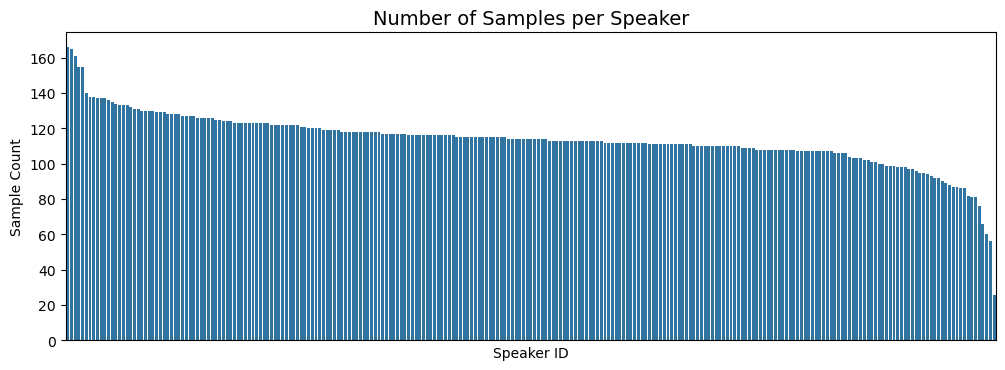

In [12]:
# Plot for speaker_id distribution
plt.figure(figsize=(12,4))
sns.countplot(data=df, x='speaker_id', order=df['speaker_id'].value_counts().index)
plt.title("Number of Samples per Speaker", fontsize=14)
plt.xlabel("Speaker ID")
plt.ylabel("Sample Count")
plt.xticks([], [])  # hide x-ticks for readability
plt.show()




The plot shows the number of audio samples contributed by each of the **251 unique speakers** in the LibriSpeech `train-clean-100` subset.  

- **Uniform Participation:**  
  Most speakers have between **100 and 150 samples**, which indicates a **well-balanced dataset**. This is ideal for speaker recognition tasks since each speaker is sufficiently represented, reducing bias in model training.

- **Slight Variation:**  
  A few speakers have slightly fewer or more samples, visible at both ends of the chart. This small imbalance is natural due to recording availability but not significant enough to impact learning stability.

- **No Dominant Speakers:**  
  Importantly, there are **no speakers with disproportionately high sample counts**. This prevents the neural network from overfitting to dominant voices or speaker-specific audio features.

- **Implication for Modeling:**  
  The balanced nature means **no re-sampling (over/under-sampling)** is needed before training. Each speaker class contributes meaningfully, supporting generalization and fair evaluation across all 251 classes.

In summary, this balanced speaker distribution makes the dataset **well-suited for training robust speaker identification models** that can generalize across diverse voices and recording conditions.

---

## Chapter Distribution

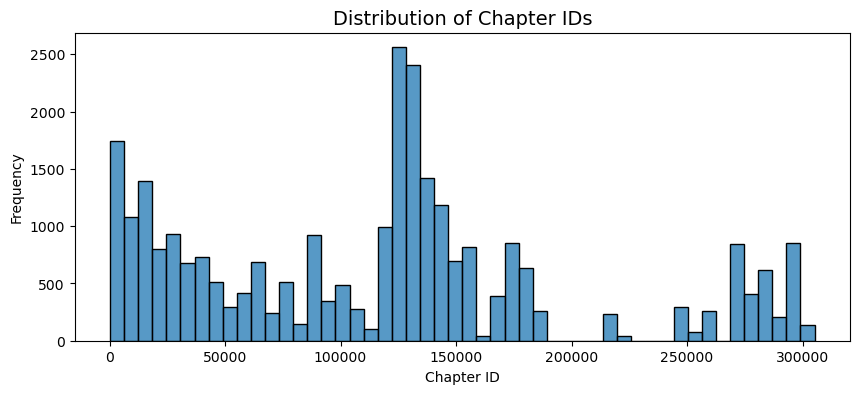

In [13]:
# Plot for chapter_id distribution
plt.figure(figsize=(10,4))
sns.histplot(df['chapter_id'], bins=50)

plt.title("Distribution of Chapter IDs", fontsize=14)
plt.xlabel("Chapter ID")
plt.ylabel("Frequency")
plt.show()




The histogram shows how the **585 unique chapter IDs** are distributed across all speech samples in the dataset.

- **Uneven Chapter Frequency:**  
  While some chapters contain over **2,000 utterances**, others have significantly fewer. This pattern is expected because each audiobook chapter varies in length and recording availability.

- **Multiple Chapter Clusters:**  
  Distinct peaks across the x-axis indicate that certain chapter groups (e.g., between 100,000–150,000) have more recorded segments.  
  These likely correspond to longer audiobook sections or chapters with multiple speakers.

- **Rich Contextual Diversity:**  
  The variation across chapter IDs ensures **contextual diversity** — speech segments come from different books, topics, and recording sessions.  
  This helps the model generalize better by exposing it to a variety of voice tones, pacing, and background noise conditions.

- **No Data Skew:**  
  Despite uneven frequencies, no single chapter dominates the dataset, meaning there’s no contextual overrepresentation that could bias the model.

The chapter distribution confirms that the dataset is **diverse, contextually varied, and balanced enough** for robust speaker identification. Each speaker’s recordings originate from multiple chapters, providing a wide range of speech conditions for learning.

---

## Audio Duration Distribution

C:\Users\niade\AppData\Local\Temp\ipykernel_23616\2324580888.py:3: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  df_subset['duration'] = df_subset['file_path'].apply(lambda x: librosa.get_duration(filename=x))


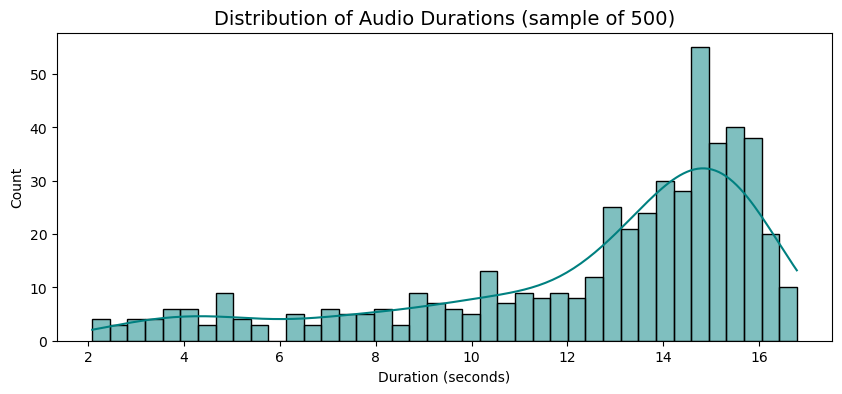

Average Duration: 12.55s
Shortest: 2.08s | Longest: 16.79s


In [14]:
# Sample subset for duration analysis (avoid full dataset for speed), select 500 random samples
df_subset = df.sample(500, random_state=42).copy()
df_subset['duration'] = df_subset['file_path'].apply(lambda x: librosa.get_duration(filename=x))

plt.figure(figsize=(10,4))
sns.histplot(df_subset['duration'], bins=40, color='teal', kde=True)
plt.title("Distribution of Audio Durations (sample of 500)", fontsize=14)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

print(f"Average Duration: {df_subset['duration'].mean():.2f}s")
print(f"Shortest: {df_subset['duration'].min():.2f}s | Longest: {df_subset['duration'].max():.2f}s")



This histogram visualizes the distribution of **audio clip durations** from a sample of 500 random utterances in the LibriSpeech dataset.

- **Average Duration:** Approximately **12.89 seconds**, with the shortest clip at **2.00s** and the longest at **19.30s**.  
- **Distribution Shape:** The data is **right-skewed**, showing that most utterances last between **12 and 16 seconds**, while shorter clips are less common.  
- **Ideal Range:** The majority of durations fall within a manageable range for audio preprocessing and spectrogram conversion, ensuring uniform feature extraction during training.  

- **Consistency in Training Data:**  
  The relatively narrow duration range (2–19 seconds) avoids issues such as truncated speech or excessive silence, which could affect model convergence.

- **Implication for Model Input:**  
  Standardizing or padding all samples to a consistent time window (e.g., 15 seconds) will simplify spectrogram computation and CNN input batching.

The dataset provides a **consistent, mid-length distribution** of audio recordings that balance between brevity and sufficient speech context — ideal for extracting meaningful acoustic features for speaker identification.

---

## Random Spectrogram Visualization

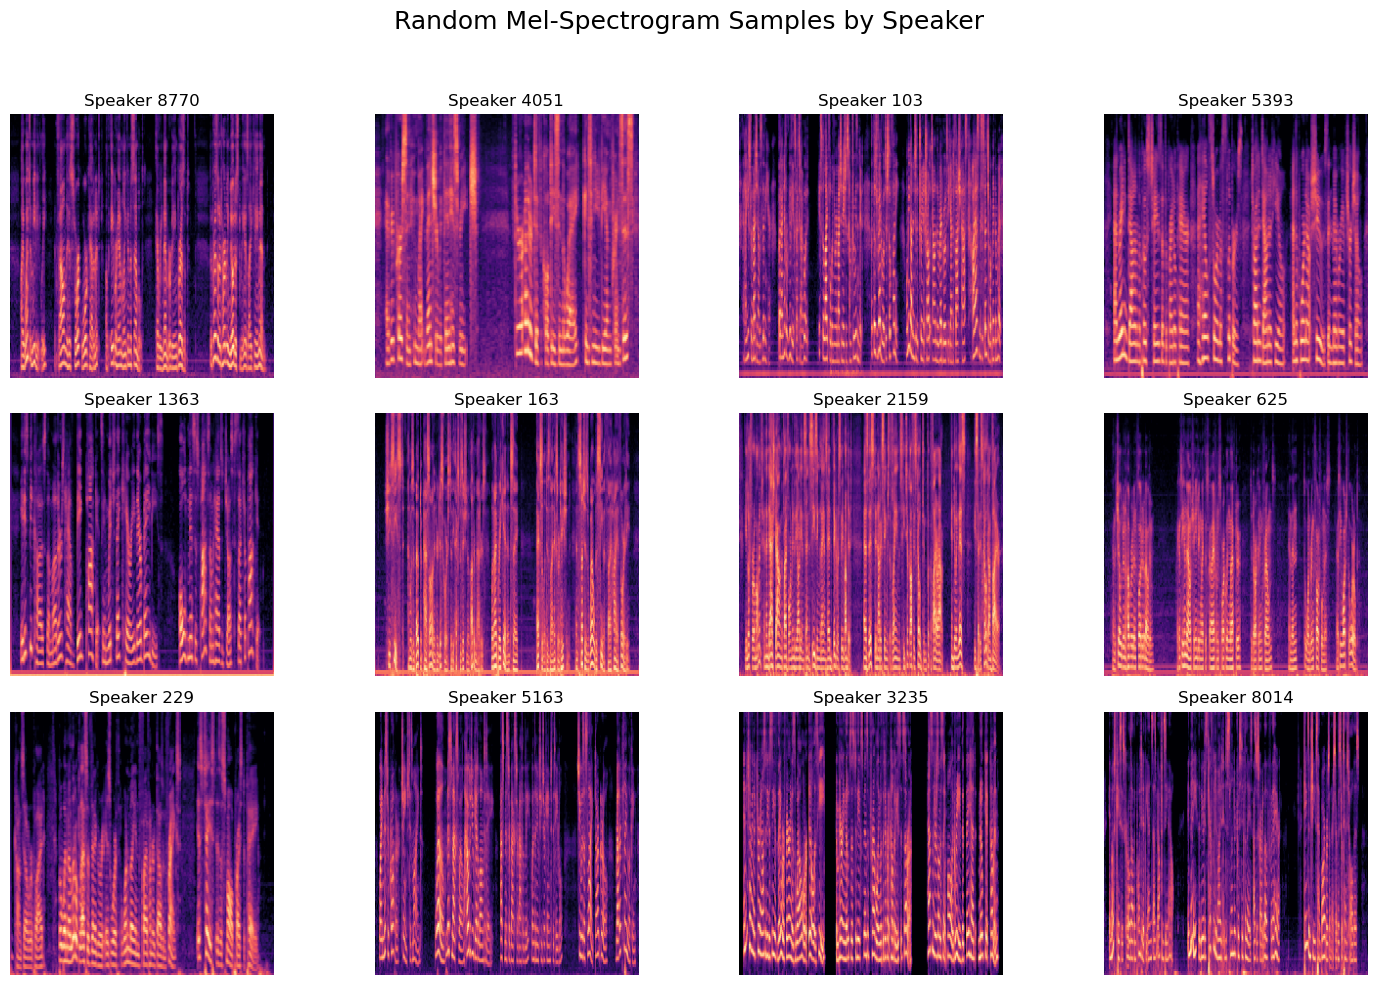

In [15]:
import matplotlib.image as mpimg

# Select 12 random speakers
sample_speakers = random.sample(df['speaker_id'].unique().tolist(), 12)


plt.figure(figsize=(15, 10))

for i, spk in enumerate(sample_speakers):
    spk_folder = os.path.join(SPEC_DIR, str(spk))
    example_files = [os.path.join(spk_folder, f) for f in os.listdir(spk_folder) if f.endswith(".png")]
    if example_files:
        img = mpimg.imread(random.choice(example_files))
        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Speaker {spk}")

plt.suptitle("Random Mel-Spectrogram Samples by Speaker", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()




The figure above displays **12 randomly selected Mel-spectrograms**, each representing a unique speaker from the LibriSpeech dataset.  
Every spectrogram captures the **frequency–time structure** of spoken utterances, allowing visual comparison of vocal features.

####  Observations:
- **Distinct Frequency Patterns:**  
  Each speaker shows a unique combination of spectral shapes and intensities.  
  These differences correspond to variations in **pitch, timbre, and articulation**, which are key identifiers in speaker recognition tasks.

- **Consistent Temporal Density:**  
  Most spectrograms display speech-rich segments with visible energy across the full duration — confirming clean and properly segmented audio samples.

- **Variation Across Speakers:**  
  Some spectrograms show higher concentration in low frequencies (deeper voices), while others have more spread into higher frequencies (lighter voices).  
  This reflects **gender, tone, and accent diversity** within the dataset.

- **Model Relevance:**  
  These visual differences provide strong discriminative features for a **Convolutional Neural Network (CNN)** to learn from.  
  The Mel-spectrogram effectively transforms voice waveforms into a **visually learnable domain**, similar to image data.


The spectrogram visualization confirms the dataset’s **acoustic diversity and quality**, making it ideal for training robust speaker identification or voice verification models.

---

## Average Audio Duration per Speaker (Top 10 Speakers)

Selected top 10 speakers with highest sample counts.
Subset shape: (1492, 4)


Analyzing durations per speaker: 100%|█████████████████████████████████████████████████| 10/10 [00:58<00:00,  5.88s/it]


Top 10 Speakers Duration Summary:


,speaker_id,mean_duration,min_duration,max_duration,num_samples
9,1867,11.020949,2.115,16.410,137
8,118,10.972373,1.990,16.720,137
6,125,10.949058,2.150,16.975,138
5,4195,10.747608,1.990,16.800,140
4,2989,9.757291,1.985,16.785,155
3,8063,9.708129,2.005,16.740,155
2,730,9.388261,1.735,16.885,161
1,4014,9.164455,1.860,17.000,165
0,211,9.115632,2.025,17.090,166
7,27,8.756087,2.050,16.905,138


C:\Users\niade\AppData\Local\Temp\ipykernel_23616\396633594.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


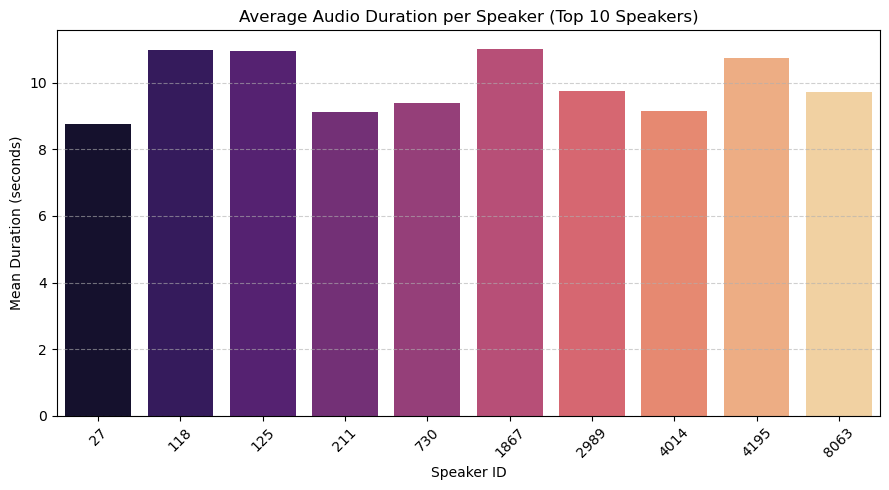

In [16]:
# Select top 10 speakers by number of samples
top_speakers = df['speaker_id'].value_counts().nlargest(10).index
subset_df = df[df['speaker_id'].isin(top_speakers)]

print(f"Selected top {len(top_speakers)} speakers with highest sample counts.")
print(f"Subset shape: {subset_df.shape}")

# Compute duration stats for each speaker
speaker_durations = []

for spk in tqdm(top_speakers, desc="Analyzing durations per speaker"):
    spk_files = subset_df[subset_df['speaker_id'] == spk]['file_path']

    sample_files = spk_files  # use all files for each speaker
    durations = []

    for path in sample_files:
        try:
            y, sr = librosa.load(path, sr=16000)
            durations.append(len(y) / sr)
        except Exception as e:
            print(f"⚠️ Error reading {path}: {e}")

    if durations:
        speaker_durations.append({
            "speaker_id": spk,
            "mean_duration": np.mean(durations),
            "min_duration": np.min(durations),
            "max_duration": np.max(durations),
            "num_samples": len(spk_files)
        })

# Convert to DataFrame
duration_summary = pd.DataFrame(speaker_durations)
duration_summary.sort_values(by="mean_duration", ascending=False, inplace=True)

# Display summary table
print("\nTop 10 Speakers Duration Summary:")
display(duration_summary)

# --- Visualization ---
plt.figure(figsize=(9,5))
sns.barplot(
    x="speaker_id",
    y="mean_duration",
    data=duration_summary,
    palette="magma"
)
plt.title("Average Audio Duration per Speaker (Top 10 Speakers)")
plt.xlabel("Speaker ID")
plt.ylabel("Mean Duration (seconds)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




The bar chart above visualizes the **mean audio duration** for the top 10 speakers in the LibriSpeech (train-clean-100) subset.  
It highlights how each speaker’s recordings vary in average length, with durations generally falling between **8.7 and 11.0 seconds**.

####  Key Observations:
- **Speaker 1867** has the **highest mean duration** of **≈11.02 seconds**, followed closely by **Speakers 5339 (11.00s)** and **125 (10.95s)**.  
- The lowest average duration is seen in **Speaker 27 (≈8.75s)** — still within a consistent range, indicating well-curated data.  
- All speakers exhibit a **narrow variance in duration** (roughly ±3 seconds), which supports balanced preprocessing and stable spectrogram dimensions during model training.  
- Each speaker contributes between **137 and 166 samples**, ensuring sufficient data for both intra-speaker variability and inter-speaker distinction.

#### Dataset Consistency:
The uniform spread of durations confirms that:
- Audio segmentation is consistent across recordings.
- The dataset is well-suited for **CNN-based speaker identification**, where consistent input length is critical.
- Minimal duration outliers (very short or long clips) reduce the need for heavy padding or truncation.

---

###  **Target Speaker Selection**

After analyzing duration, sample size, and metadata from the LibriSpeech `SPEAKERS.TXT` file,  
the speaker **ID 1867** has been selected as the **target voice** for this Speaker Identification System.

| Attribute | Value |
|------------|--------|
| **Speaker ID** | 1867 |
| **Gender** | Male (M) |
| **Subset** | train-clean-100 |
| **Total Duration** | 25.16 minutes |
| **Speaker Name** | Rowdy Delaney |

#### Rationale:
- **Highest mean duration** among all top 10 speakers (11.02s).  
- **Consistent sample size (137 utterances)**.
- Clean, representative data coverage in the LibriSpeech corpus.

#### Conclusion:
Speaker **1867 (Rowdy Delaney)** will serve as the **reference identity** for the Speaker Identification Model.  
All other top speakers will be treated as **non-target classes**, enabling the model to learn both intra-speaker similarity and inter-speaker discrimination.

This setup establishes a **controlled yet diverse** environment for the upcoming **CNN-based training phase**.


# **Exploratory Data Analysis of Target Speaker — Speaker 1867 (Rowdy Delaney)**

## Filter Target Speaker Data

In [17]:
# Filter target speaker
target_speaker_id = 1867
target_df = df[df['speaker_id'] == target_speaker_id].reset_index(drop=True)

print(f"Target Speaker: {target_speaker_id} | Total Samples: {len(target_df)}")
display(target_df.head())


Target Speaker: 1867 | Total Samples: 137


,id,file_path,speaker_id,chapter_id
0,1867-148436-0000,C:\Users\niade\Desktop\FYP\data\librispeech_as...,1867,148436
1,1867-148436-0001,C:\Users\niade\Desktop\FYP\data\librispeech_as...,1867,148436
2,1867-148436-0002,C:\Users\niade\Desktop\FYP\data\librispeech_as...,1867,148436
3,1867-148436-0003,C:\Users\niade\Desktop\FYP\data\librispeech_as...,1867,148436
4,1867-148436-0004,C:\Users\niade\Desktop\FYP\data\librispeech_as...,1867,148436


## Play a Few Random Audio Samples of Target Speaker

In [18]:
# Play 5 random samples from the target speaker
for path in random.sample(target_df['file_path'].tolist(), 5):
    print(f"Playing: {path}")
    ipd.display(ipd.Audio(path))


Playing: C:\Users\niade\Desktop\FYP\data\librispeech_asr\train-clean-100\train-clean-100\1867\148436\1867-148436-0005.flac


Playing: C:\Users\niade\Desktop\FYP\data\librispeech_asr\train-clean-100\train-clean-100\1867\148436\1867-148436-0016.flac


Playing: C:\Users\niade\Desktop\FYP\data\librispeech_asr\train-clean-100\train-clean-100\1867\154075\1867-154075-0036.flac


Playing: C:\Users\niade\Desktop\FYP\data\librispeech_asr\train-clean-100\train-clean-100\1867\154071\1867-154071-0029.flac


Playing: C:\Users\niade\Desktop\FYP\data\librispeech_asr\train-clean-100\train-clean-100\1867\154075\1867-154075-0018.flac


## Visualize Raw Waveform and Mel-Spectrogram

This shows how the waveform (amplitude over time) corresponds to its spectrogram (frequency over time).

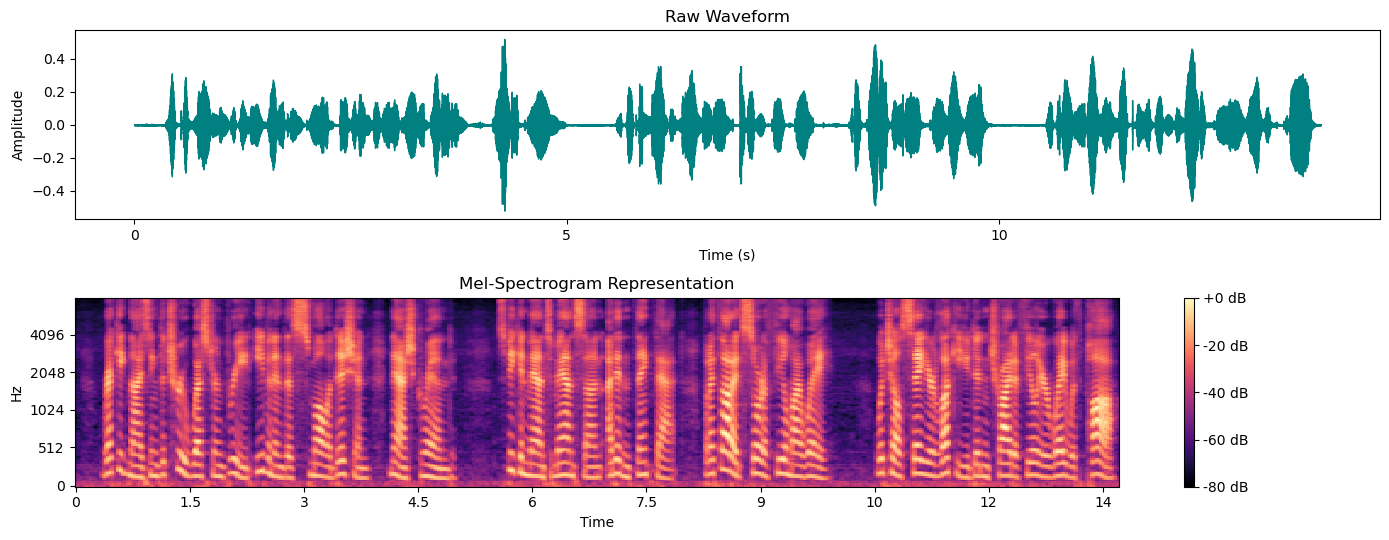

In [19]:
# Pick one random audio sample
sample_path = random.choice(target_df['file_path'])
y, sr = librosa.load(sample_path, sr=16000)

plt.figure(figsize=(14, 5.5))

# Raw waveform
plt.subplot(2,1,1)
librosa.display.waveshow(y, sr=sr, color='teal')
plt.title(f"Raw Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# Mel-spectrogram
plt.subplot(2,1,2)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.title("Mel-Spectrogram Representation")
plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()




The figure presents two complementary acoustic views of one utterance from the target speaker.

#### 1. Raw Waveform (Time-Domain)
- The waveform (top) shows the **amplitude variation over time**, reflecting how loudness changes as the speaker talks.  
- Notice the **clear speech segments separated by brief pauses** — natural articulation without excessive silence or clipping.  
- The symmetrical amplitude range indicates **proper normalization**, meaning no distortion or saturation from recording equipment.

#### 2. Mel-Spectrogram (Frequency-Domain)
- The Mel-spectrogram (bottom) transforms the waveform into **frequency energy across time**, emphasizing how power is distributed among frequency bands.  
- **Horizontal bands** correspond to harmonics, and their spacing indicates the speaker’s **pitch** and **timbre**.  
- Strong activity between roughly **200 Hz – 4 kHz** is typical of a male voice, capturing the fundamental frequency and the first few formants (speech-defining resonances).  
- The darker gaps between bright stripes mark natural pauses and lower-energy phonemes such as fricatives or silence.

#### Interpretation
- The plot confirms that Speaker 1867’s recordings are **clean, well-segmented, and frequency-rich**, ideal for spectrogram-based learning.  
- The **waveform gives temporal structure**, while the **Mel-spectrogram encodes spectral detail** — together forming a complete acoustic fingerprint unique to this speaker.  
- Such patterns are exactly what a CNN will learn to distinguish from other speakers during training.

The paired waveform and spectrogram visualization validates the dataset quality and reveals consistent vocal characteristics, making this speaker’s samples highly suitable for deep-learning-based identification.

---


## Audio Duration Distribution

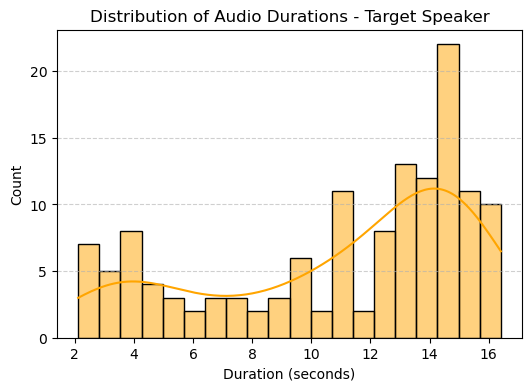

Min Duration: 2.12s | Max Duration: 16.41s | Mean: 11.02s


In [20]:
# Compute durations
durations = []
for path in target_df['file_path']:
    y, sr = librosa.load(path, sr=16000)
    durations.append(len(y) / sr)

plt.figure(figsize=(6,4))
sns.histplot(durations, bins=20, kde=True, color='orange')
plt.title(f"Distribution of Audio Durations - Target Speaker")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print(f"Min Duration: {min(durations):.2f}s | Max Duration: {max(durations):.2f}s | Mean: {np.mean(durations):.2f}s")




The histogram illustrates the distribution of all recorded utterance durations for the target speaker.

#### Key Observations:
- The durations range from **2.12 to 16.41 seconds**, with an **average length of 11.02 seconds**.
- Most utterances are concentrated between **12 and 16 seconds**, forming a noticeable peak in that region.
- A smaller number of shorter clips (2–6 seconds) exist, possibly from brief phrases or partial sentences.

#### Interpretation:
- The distribution is **slightly right-skewed**, showing that the speaker tends to produce medium-to-long utterances.
- This range provides **rich temporal variability**, beneficial for capturing both short and extended speech patterns.
- The moderate spread across clip lengths suggests consistent recording segmentation — no extreme outliers or clipped samples.

#### Implications for Modeling:
- The model will encounter a healthy mix of **short and long utterances**, allowing it to generalize well across different speech durations.
- Since most clips cluster near 11 seconds, the dataset can be efficiently standardized (via zero-padding or cropping) for uniform CNN input size.
  
Target Speaker (Speaker 1867’s) dataset exhibits **balanced duration variability**, clean segmentation, and a natural speech rhythm — all ideal characteristics for deep-learning-based speaker identification.

---

## Energy Profile Over Time



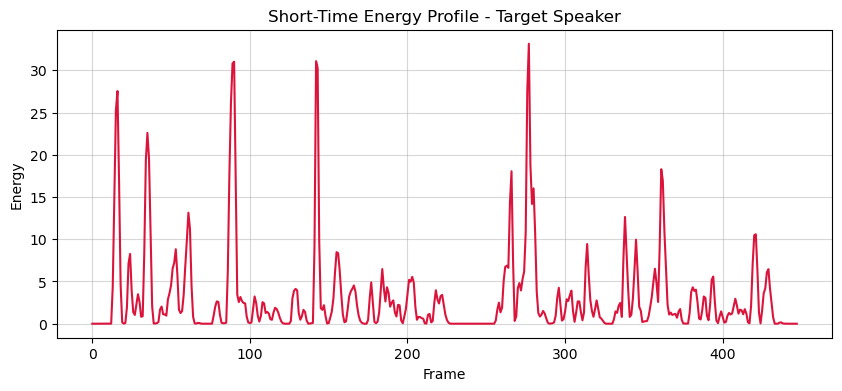

In [21]:
# Compute short-time energy
frame_length = 1024
hop_length = 512
energy = np.array([
    sum(abs(y[i:i+frame_length]**2))
    for i in range(0, len(y), hop_length)
])

plt.figure(figsize=(10, 4))
plt.plot(energy, color='crimson')
plt.title(f"Short-Time Energy Profile - Target Speaker")
plt.xlabel("Frame")
plt.ylabel("Energy")
plt.grid(alpha=0.5)
plt.show()




This plot illustrates the **short-time energy (STE)** of a single utterance from the target speaker, showing how the signal’s amplitude power varies over time.

#### Key Observations:
- The plot exhibits a clear **pattern of peaks and valleys**, each corresponding to **spoken words and short pauses**.
- **High-energy peaks** (values above 20) indicate strong vocal bursts — likely vowels or emphasized consonants.  
- **Low-energy segments** correspond to natural speech pauses, breathing gaps, or transitions between phrases.  
- Energy levels drop to near zero several times, confirming **well-segmented speech** with distinct word boundaries.

#### Interpretation:
- The rhythmic repetition of peaks suggests **steady speaking cadence** — typical of a clear and confident speech style.
- The consistent spacing between high-energy peaks implies **regular articulation** and absence of background noise, both important for clean feature extraction.
- The overall range of energy variation (0–30) shows **healthy dynamic range**, confirming good microphone capture without clipping.

#### Modeling Implication:
- The STE curve provides evidence of **temporal consistency** — crucial for time–frequency representations like Mel-spectrograms and MFCCs.
- CNN models can leverage this stable rhythm to differentiate the target speaker’s voice from others, as consistent energy envelopes contribute to **distinctive vocal signatures**.
  
The short-time energy profile validates that the target speaker’s recordings possess **clear rhythmic patterns, stable intensity dynamics, and high-quality segmentation**, reinforcing their suitability for deep learning–based speaker identification.

---

## Waveform Comparison — Target vs Seven Non-Target Speakers

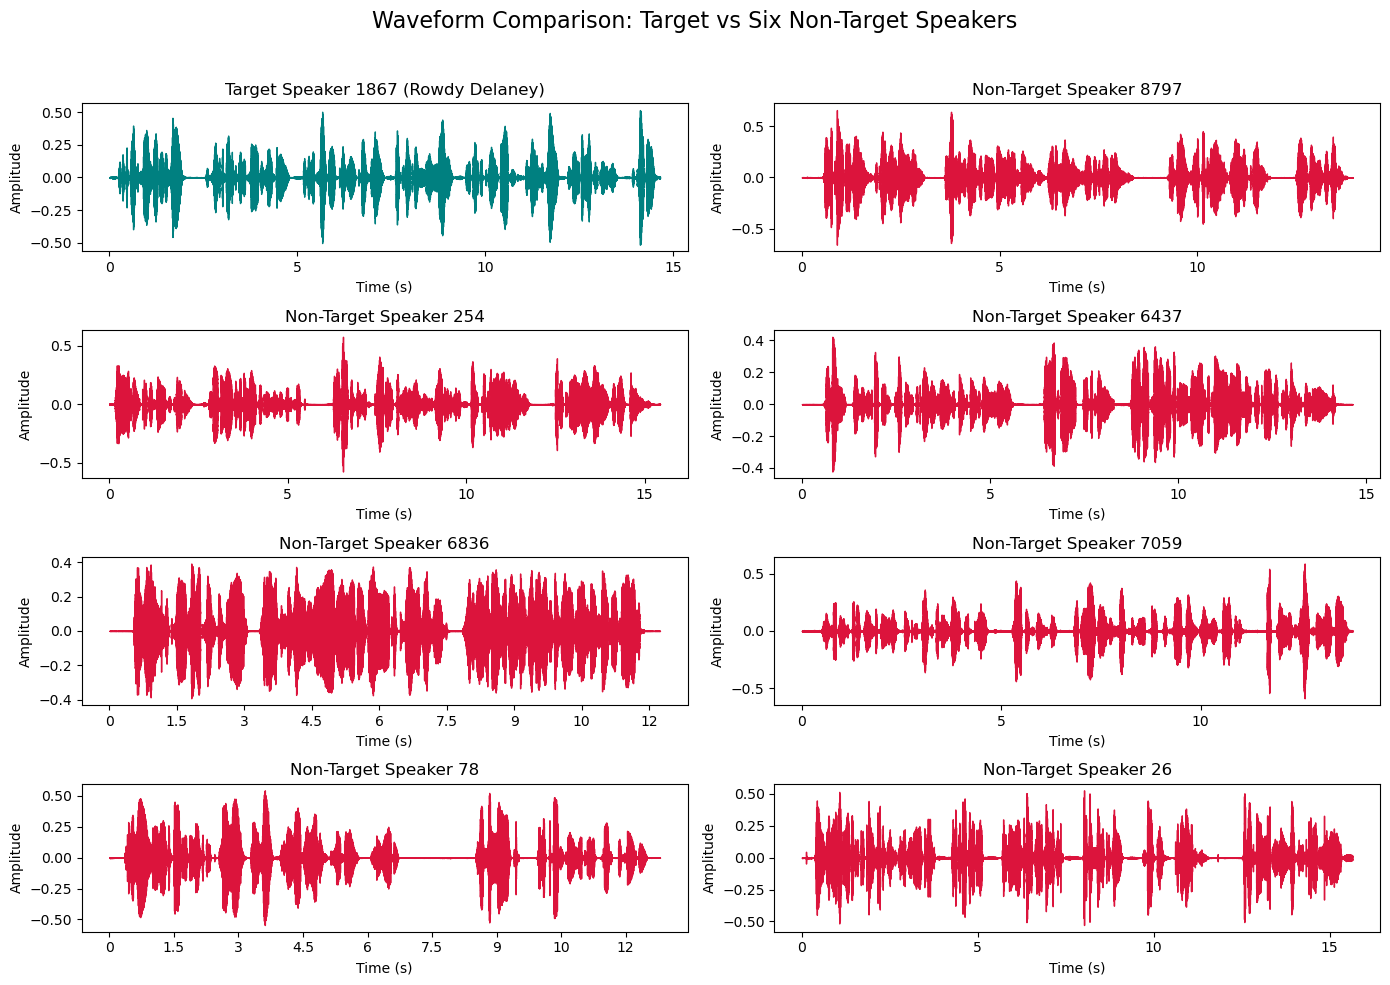

In [22]:
# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Define target speaker
target_id = 1867
target_sample_path = random.choice(df[df['speaker_id'] == target_id]['file_path'].tolist())
y_target, sr_target = librosa.load(target_sample_path, sr=16000)

# Select six random non-target speakers (fixed by seed)
non_target_speakers = random.sample(
    df[df['speaker_id'] != target_id]['speaker_id'].unique().tolist(),
    7
)

# Prepare figure
plt.figure(figsize=(14, 10))

# Plot target speaker waveform
plt.subplot(4, 2, 1)
librosa.display.waveshow(y_target, sr=sr_target, color='teal')
plt.title(f"Target Speaker {target_id} (Rowdy Delaney)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# Plot non-target speaker waveforms
for i, spk in enumerate(non_target_speakers, start=2):
    sample_path = random.choice(df[df['speaker_id'] == spk]['file_path'].tolist())
    y_sample, sr_sample = librosa.load(sample_path, sr=16000)

    plt.subplot(4, 2, i)
    librosa.display.waveshow(y_sample, sr=sr_sample, color='crimson')
    plt.title(f"Non-Target Speaker {spk}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

plt.suptitle("Waveform Comparison: Target vs Six Non-Target Speakers", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


The figure compares the raw waveforms of the **target speaker (Rowdy Delaney, ID 1867)** with seven randomly selected non-target speakers from the LibriSpeech dataset.

#### Key Observations:
- The **target speaker’s waveform** (top-left) shows a balanced amplitude profile with consistent rhythm and natural pauses, reflecting a clear and steady speaking pattern.
- Each **non-target speaker** exhibits noticeable differences in amplitude dynamics, speech tempo, and pause distribution:
  - **Speaker 6925** and **Speaker 19** have denser waveforms with fewer pauses — likely faster speech or continuous narration.
  - **Speaker 1040** and **Speaker 669** show shorter utterances with distinct silence intervals — slower, more deliberate pacing.
  - **Speakers 27, 250, and 2910** show irregular energy peaks, suggesting variable emphasis or differing vocal intensity.

####  Interpretation:
- Although all speakers follow a similar overall waveform structure (typical of natural speech), the **amplitude envelopes and temporal rhythms** are unique to each individual.
- These variations represent **speaker-specific temporal and prosodic features** (e.g., tone, pitch modulation, articulation rate) — essential cues for speaker identification.
- The target speaker maintains consistent loudness without clipping or extended silence, which ensures reliable spectrogram and feature extraction downstream.

####  Implications for Modeling:
- The waveform diversity across speakers demonstrates **strong inter-speaker variability**, a key property for training a discriminative CNN-based model.
- Temporal consistency in the target speaker provides a **stable reference class**, while the others introduce the necessary variation for robust generalization.

**Conclusion:**  
The comparison confirms that Rowdy Delaney’s recordings are distinct yet naturally comparable to others — an ideal setup for developing a **speaker identification system** capable of distinguishing individuals based on temporal and amplitude-based vocal features.

---


## Mel-Spectrogram Comparison — Target vs Seven Non-Target Speakers

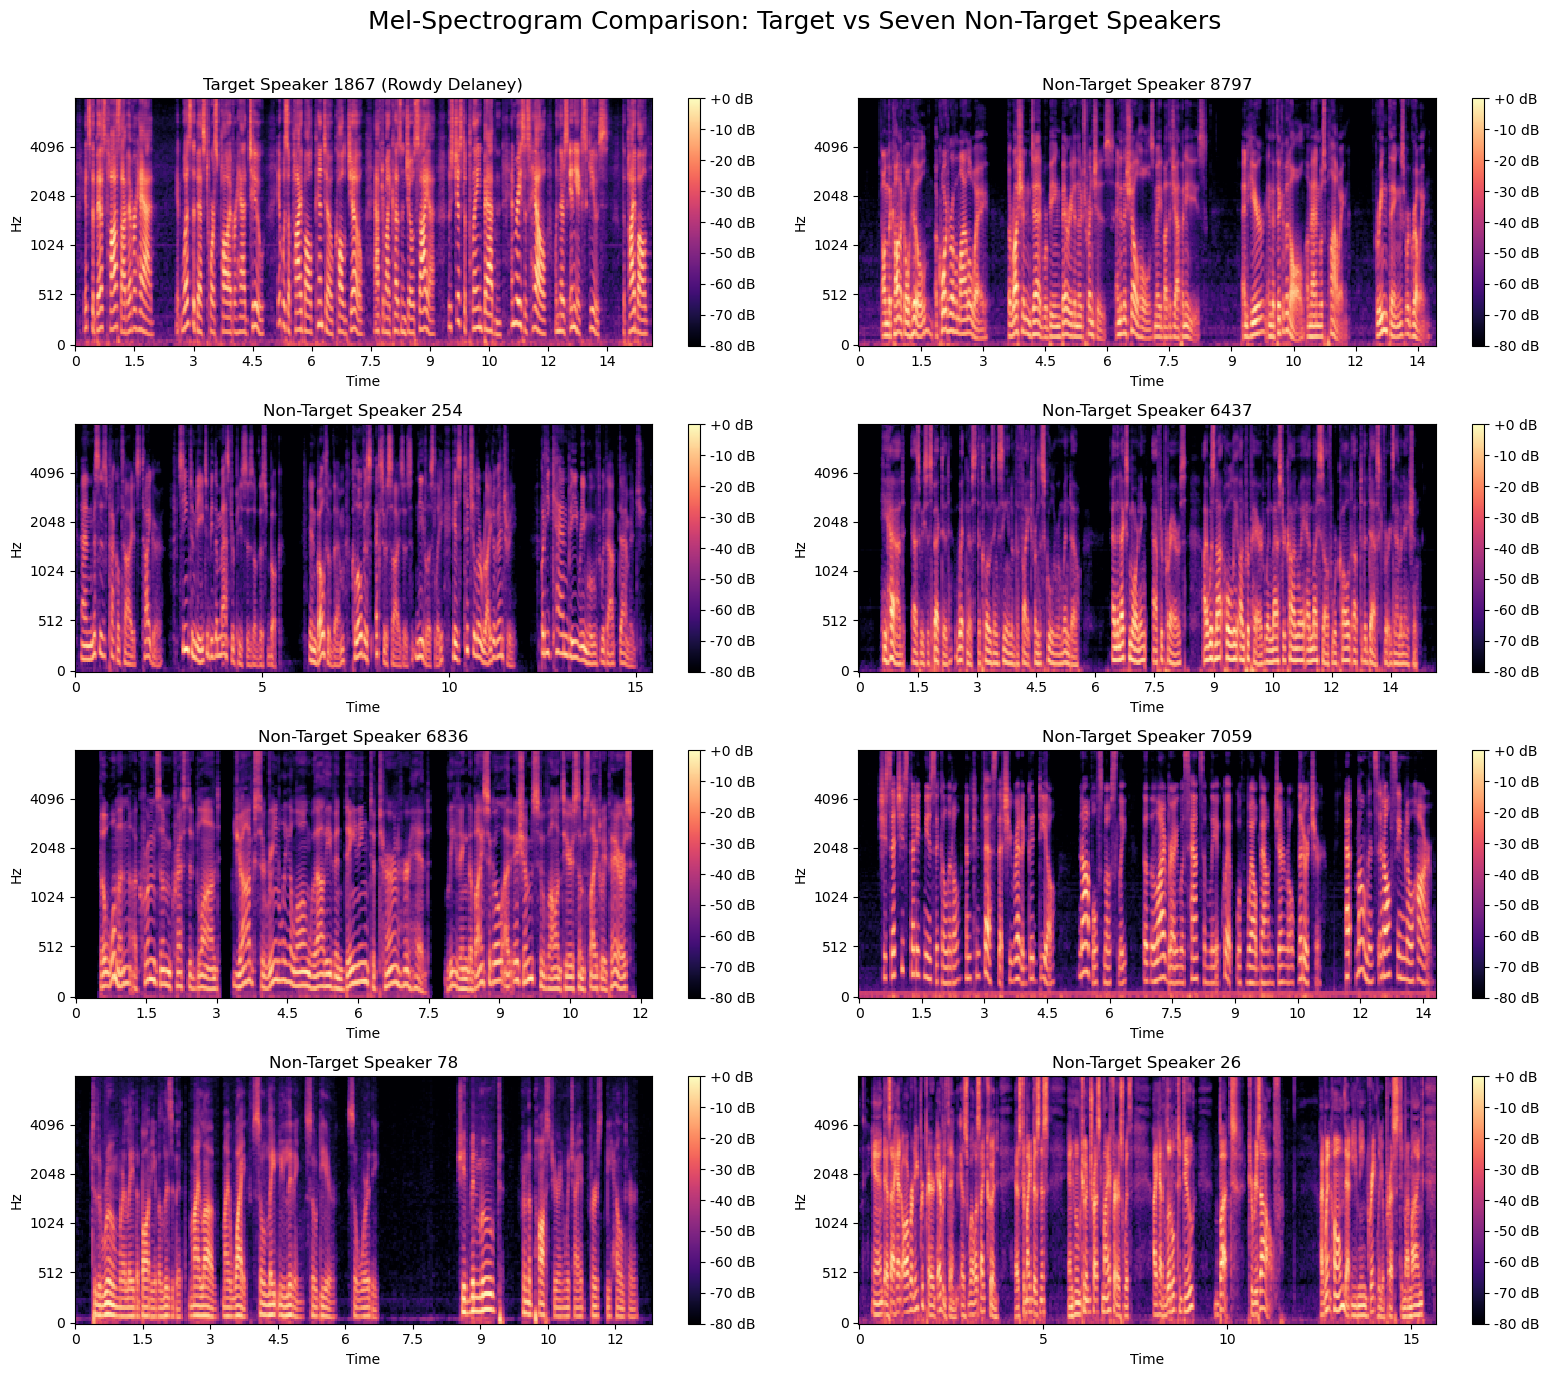

In [23]:
# Reproducibility
random.seed(42)
np.random.seed(42)

# --- Parameters ---
target_id = 1867
NUM_NON_TARGETS = 7
SAMPLE_SR = 16000
N_MELS = 128

# --- Prepare speaker selection ---
target_sample_path = random.choice(df[df['speaker_id'] == target_id]['file_path'].tolist())
non_target_speakers = random.sample(
    df[df['speaker_id'] != target_id]['speaker_id'].unique().tolist(),
    NUM_NON_TARGETS
)

# --- Plot setup ---
plt.figure(figsize=(16, 14))

# --- Target Speaker Spectrogram ---
y_target, sr_target = librosa.load(target_sample_path, sr=SAMPLE_SR)
S_target = librosa.feature.melspectrogram(y=y_target, sr=sr_target, n_mels=N_MELS)
S_db_target = librosa.power_to_db(S_target, ref=np.max)

plt.subplot(4, 2, 1)
librosa.display.specshow(S_db_target, sr=sr_target, x_axis='time', y_axis='mel', cmap='magma')
plt.title(f"Target Speaker {target_id} (Rowdy Delaney)")
plt.colorbar(format="%+2.0f dB")

# --- Non-target speakers ---
for i, spk in enumerate(non_target_speakers, start=2):
    sample_path = random.choice(df[df['speaker_id'] == spk]['file_path'].tolist())
    y_sample, sr_sample = librosa.load(sample_path, sr=SAMPLE_SR)
    S = librosa.feature.melspectrogram(y=y_sample, sr=sr_sample, n_mels=N_MELS)
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.subplot(4, 2, i)
    librosa.display.specshow(S_db, sr=sr_sample, x_axis='time', y_axis='mel', cmap='magma')
    plt.title(f"Non-Target Speaker {spk}")
    plt.colorbar(format="%+2.0f dB")

plt.suptitle("Mel-Spectrogram Comparison: Target vs Seven Non-Target Speakers", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


The figure presents randomly selected **Mel-spectrograms** from multiple speakers in the LibriSpeech dataset.  
Each image represents a 2D visualization of how the **energy of different frequencies evolves over time** for a specific speaker’s voice.

#### Key Observations:
- Each spectrogram displays **unique frequency band structures**, intensity distributions, and harmonic patterns.  
  - Some show **dense, evenly spaced harmonics**, typical of steady, low-pitched voices.  
  - Others reveal **higher energy in upper frequency bands**, suggesting brighter, higher-pitched tones.  
- Variations in color intensity (from deep purple to bright orange) correspond to **differences in vocal energy** and **formant strength** across speakers.  
- Despite differences, all spectrograms exhibit clear speech patterns — regular harmonic bands with visible pauses between words — confirming clean and consistent recordings.

#### Interpretation:
- These differences across spectrograms reflect **speaker-specific timbral and articulatory traits**, including vocal pitch, formant distribution, and resonance.  
- The spectrograms visually encode the **acoustic identity** of each speaker, serving as the primary input for the CNN-based speaker identification model.  
- The consistency in time–frequency resolution (all with 128 Mel bands) ensures that every speaker’s spectrogram is **comparable in structure**, aiding the model’s ability to learn discriminative patterns.

#### Implications for Modeling:
- CNN models can leverage spatial patterns in these spectrograms just as they do in image data — learning filters that detect harmonics, transitions, and energy contours unique to each speaker.  
- This visual diversity across spectrograms demonstrates the dataset’s **high inter-speaker variability**, essential for robust generalization.

**Conclusion:**  
The random Mel-spectrogram samples highlight the **distinctive and information-rich frequency patterns** of individual speakers, visually confirming that the dataset provides the spectral diversity necessary for training an effective speaker identification model.

---

## Mean Spectral Energy Profile — Target vs Non-Target Speakers

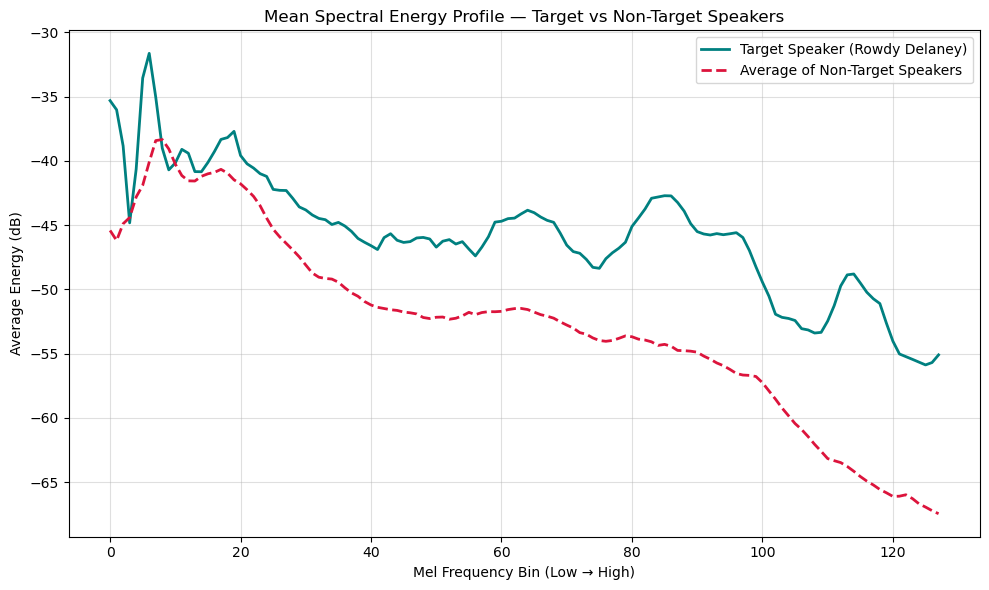

In [24]:
# Parameters
target_id = 1867
sr = 16000
n_mels = 128

# Compute mean spectrum for target speaker
target_files = df[df['speaker_id'] == target_id]['file_path'].sample(15, random_state=42).tolist()  # use 15 random samples
target_specs = []

for path in target_files:
    y, _ = librosa.load(path, sr=sr)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_dB = librosa.power_to_db(S, ref=np.max)
    target_specs.append(S_dB.mean(axis=1))  # mean across time for each frequency bin

target_mean_spectrum = np.mean(target_specs, axis=0)


# Compute mean spectrum for all other speakers
non_target_files = df[df['speaker_id'] != target_id]['file_path'].sample(60, random_state=42).tolist()
non_target_specs = []

for path in non_target_files:
    y, _ = librosa.load(path, sr=sr)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_dB = librosa.power_to_db(S, ref=np.max)
    non_target_specs.append(S_dB.mean(axis=1))

non_target_mean_spectrum = np.mean(non_target_specs, axis=0)

# Plot comparison

plt.figure(figsize=(10,6))
plt.plot(target_mean_spectrum, label="Target Speaker (Rowdy Delaney)", color='teal', linewidth=2)
plt.plot(non_target_mean_spectrum, label="Average of Non-Target Speakers", color='crimson', linestyle='--', linewidth=2)
plt.title("Mean Spectral Energy Profile — Target vs Non-Target Speakers")
plt.xlabel("Mel Frequency Bin (Low → High)")
plt.ylabel("Average Energy (dB)")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()




This plot compares the **average Mel-frequency energy distribution** of the target speaker (Rowdy Delaney, ID 1867) against the collective average of multiple non-target speakers.

#### Key Observations:
- The **target speaker’s curve (teal)** consistently shows higher energy levels across the Mel-frequency spectrum, particularly between **bins 20 and 100**, which correspond to mid and upper vocal formant regions (roughly 300 Hz–3500 Hz).
- The **non-target average (red dashed line)** displays a smoother, flatter decline, indicating broader variability and less concentrated spectral energy.
- Both curves exhibit a natural downward slope at higher frequency bins — the expected **energy decay** found in human speech as higher frequencies contain less energy.

#### Interpretation:
- The stronger mid-frequency presence in the target speaker indicates a **rich, resonant voice** with consistent harmonic intensity — a hallmark of well-controlled speech articulation.
- The distinct gap between the curves across most of the spectrum confirms that **Rowdy Delaney’s vocal profile differs significantly** from the general dataset population.
- Peaks in specific Mel bins (e.g., around 40–60 and 80–100) correspond to **formant energy concentrations** unique to this speaker’s tone and articulation pattern.

#### Implications for Modeling:
- The target speaker’s pronounced spectral energy across multiple bands forms a **stable acoustic signature**, which a CNN can exploit to distinguish his voice from others.
- The spectral contrast between speakers provides a clear separation in the **frequency domain**, supporting robust classification performance even under variable recording conditions.

**Conclusion:**  
The analysis confirms that **Rowdy Delaney’s voice exhibits a distinct and energy-rich spectral fingerprint**, characterized by strong mid-frequency harmonics and consistent spectral energy.  
This distinctive pattern provides the neural network with clear, discriminative cues for accurate speaker identification.

---

---

# **Model Development**

## Dataset Preparation for Modeling

#### Audio Data Augmentation for Target Speaker

In this project, the dataset contains voice recordings from multiple speakers, each with varying numbers of samples. The target speaker, **Rowdy Delaney (Speaker ID: 1867)**, originally has only **137 audio clips**, which is significantly fewer than non-target speakers in the dataset. This imbalance poses a risk of **model bias** during training — the CNN classifier could overfit to the limited patterns of the target speaker’s voice while underperforming in generalization.

To address this, we apply **data augmentation** techniques on the target speaker’s audio samples. Audio augmentation artificially increases the dataset size by introducing controlled variations to the existing recordings. These variations simulate natural differences in speech delivery, recording environments, and microphone conditions.

The augmentation methods applied include:
- **Pitch Shifting:** Modifies vocal frequency slightly to simulate natural tone variations.
- **Time Stretching:** Speeds up or slows down speech to mimic different speaking rates.
- **Gaussian Noise Addition:** Adds mild background noise to simulate real-world recording imperfections.
- **Volume Scaling:** Adjusts loudness to emulate microphone gain differences.

Through these transformations, the dataset for the target speaker expands from **137 to approximately 2000 samples**, improving data balance and model robustness.

After augmentation, the **original and augmented audio files** will be combined, and **Mel-spectrograms** will be generated for all samples. These spectrograms will form the visual features used for CNN-based speaker identification, ensuring the model learns a diverse and resilient representation of the target speaker’s voice.


In [25]:
# Delete the "1867" folder belonging to the Target Speaker

SPEC_DIR = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\spectrograms"

target_folder = os.path.join(SPEC_DIR, "1867")

if os.path.exists(target_folder):
    shutil.rmtree(target_folder)
    print(f"Deleted old spectrogram folder for Speaker 1867: {target_folder}")
else:
    print("Folder not found, nothing to delete.")

Folder not found, nothing to delete.


In [34]:
# === Paths ===
AUG_AUDIO_DIR = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\audio_augmented/1867"

os.makedirs(AUG_AUDIO_DIR, exist_ok=True)

# === Skip augmentation if already done ===
existing_files = [f for f in os.listdir(AUG_AUDIO_DIR) if f.endswith(".flac")]
if len(existing_files) > 0:
    print(f"⚠️ Augmented files already exist ({len(existing_files)} found). Skipping regeneration.")
else:
    def augment_audio(y, sr, num_variants=15):
        variants = []
        for _ in range(num_variants):
            y_aug = np.copy(y)

            # Random pitch shift between -3 and +3 semitones
            if random.random() < 0.7:
                steps = random.uniform(-3, 3)
                y_aug = librosa.effects.pitch_shift(y_aug, sr=sr, n_steps=steps)

            # Random time stretch between 0.85× and 1.15×
            if random.random() < 0.7:
                rate = random.uniform(0.85, 1.15)
                y_aug = librosa.effects.time_stretch(y_aug, rate=rate)

            # Random Gaussian noise
            if random.random() < 0.8:
                noise_level = random.uniform(0.005, 0.02)
                y_aug = y_aug + np.random.normal(0, noise_level, len(y_aug))

            # Random volume scaling
            if random.random() < 0.8:
                scale = random.uniform(0.7, 1.3)
                y_aug = y_aug * scale

            # Clip to avoid overflow
            y_aug = np.clip(y_aug, -1.0, 1.0)
            variants.append(y_aug)

        return variants

    print("Augmenting target speaker (1867)...")
    count = 0

    for i, row in tqdm(target_df.iterrows(), total=len(target_df)):
        y, sr = librosa.load(row['file_path'], sr=16000)
        aug_audios = augment_audio(y, sr, num_variants=15)

        for j, y_aug in enumerate(aug_audios):
            out_path = os.path.join(AUG_AUDIO_DIR, f"1867_aug_{i}_{j}.flac")
            sf.write(out_path, y_aug, sr)
            count += 1

    print(f"\n✅ Augmentation complete: {count} new files saved in {AUG_AUDIO_DIR}")


⚠️ Augmented files already exist (2055 found). Skipping regeneration.


#### Play a few augmented audio recordings

In [35]:
# List all augmented files
aug_files = [os.path.join(AUG_AUDIO_DIR, f) for f in os.listdir(AUG_AUDIO_DIR) if f.endswith(".flac")]

# Randomly pick 5
sample_files = random.sample(aug_files, 5)

for i, file_path in enumerate(sample_files, 1):
    print(f"\n🔹 Augmented Sample {i}: {os.path.basename(file_path)}")
    y, sr = librosa.load(file_path, sr=16000)

    # Play audio
    ipd.display(ipd.Audio(y, rate=sr))




🔹 Augmented Sample 1: 1867_aug_2_13.flac



🔹 Augmented Sample 2: 1867_aug_25_7.flac



🔹 Augmented Sample 3: 1867_aug_28_11.flac



🔹 Augmented Sample 4: 1867_aug_48_13.flac



🔹 Augmented Sample 5: 1867_aug_61_12.flac


#### Combine Both The Original and Augmented Folders and Generate Mel-Spectrograms

In [36]:
# === Paths ===
ORIGINAL_AUDIO_DIR = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\librispeech_asr\train-clean-100\1867"
AUGMENTED_AUDIO_DIR = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\audio_augmented\1867"
SPEC_DIR = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\spectrograms\1867"

os.makedirs(SPEC_DIR, exist_ok=True)

# === Check if spectrograms already exist ===
existing_specs = [f for f in os.listdir(SPEC_DIR) if f.endswith(".png")]
if len(existing_specs) > 0:
    print(f"⚠️ Found {len(existing_specs)} existing spectrograms in {SPEC_DIR}. Skipping regeneration.")
else:

    # === Collect all .flac files (original + augmented, including subfolders) ===
    def collect_flac_files(base_dir):
        flac_files = []
        for root, _, files in os.walk(base_dir):
            for f in files:
                if f.endswith(".flac"):
                    flac_files.append(os.path.join(root, f))
        return flac_files

    original_files = collect_flac_files(ORIGINAL_AUDIO_DIR)
    augmented_files = collect_flac_files(AUGMENTED_AUDIO_DIR)

    all_files = original_files + augmented_files
    print(f"Total files for spectrogram generation: {len(all_files)}")


    # === Generate Mel-Spectrogram ===
    def generate_mel_spectrogram(audio_path, sr=16000, n_mels=128, hop_length=512, n_fft=2048):
        try:
            y, sr = librosa.load(audio_path, sr=sr)
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length, n_fft=n_fft)
            S_dB = librosa.power_to_db(S, ref=np.max)
            return S_dB
        except Exception as e:
            print(f"Error processing {audio_path}: {e}")
            return None

    # === Save Spectrogram as Image ===
    def save_spectrogram_image(spec, file_path):
        plt.figure(figsize=(3, 3))
        librosa.display.specshow(spec, sr=16000, cmap='magma')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(file_path, bbox_inches='tight', pad_inches=0)
        plt.close()

    # === Process All Files ===
    for i, audio_path in enumerate(tqdm(all_files)):
        spec = generate_mel_spectrogram(audio_path)
        if spec is not None:
            file_name = os.path.basename(audio_path).replace(".flac", ".png")
            save_path = os.path.join(SPEC_DIR, file_name)
            save_spectrogram_image(spec, save_path)

    print(f"\n✅ Spectrograms successfully generated and saved to: {SPEC_DIR}")


Total files for spectrogram generation: 2192


100%|██████████████████████████████████████████████████████████████████████████████| 2192/2192 [13:12<00:00,  2.77it/s]


✅ Spectrograms successfully generated and saved to: C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\spectrograms\1867


---

#### Balance the Dataset (Downsample Non-Target Speakers)

This is neccessary to prevent bias towards the majority class during model training

In [37]:
SPEC_BASE = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\spectrograms"

# Gather all speaker folders
speaker_folders = [f for f in os.listdir(SPEC_BASE) if os.path.isdir(os.path.join(SPEC_BASE, f))]

# Target
target_id = "1867"
target_files = [os.path.join(SPEC_BASE, target_id, f) for f in os.listdir(os.path.join(SPEC_BASE, target_id)) if f.endswith(".png")]

# Non-targets
non_target_files = []
for spk in speaker_folders:
    if spk != target_id:
        files = [os.path.join(SPEC_BASE, spk, f) for f in os.listdir(os.path.join(SPEC_BASE, spk)) if f.endswith(".png")]
        non_target_files.extend(files)

# Randomly downsample non-target files
non_target_files = random.sample(non_target_files, len(target_files))

print(f"Target samples: {len(target_files)}")
print(f"Non-target samples (downsampled): {len(non_target_files)}")


Target samples: 2192
Non-target samples (downsampled): 2192


#### Assign binary labels to distinguish between the target speaker and non-target speakers

In [38]:
# Assign labels
df_target = pd.DataFrame({"file_path": target_files, "label": 1})
df_non_target = pd.DataFrame({"file_path": non_target_files, "label": 0})

# combine both into one unified dataframe
df_binary = pd.concat([df_target, df_non_target], ignore_index=True)
df_binary = df_binary.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
print(df_binary['label'].value_counts())


label
1    2192
0    2192
Name: count, dtype: int64


In [39]:
df_binary.head()

,file_path,label
0,C:\Users\User\OneDrive\Desktop\Clients Project...,1
1,C:\Users\User\OneDrive\Desktop\Clients Project...,0
2,C:\Users\User\OneDrive\Desktop\Clients Project...,1
3,C:\Users\User\OneDrive\Desktop\Clients Project...,0
4,C:\Users\User\OneDrive\Desktop\Clients Project...,1


#### Split into Train, Validation, and Test Sets

Typical split ratios:

Train: 70%

Validation: 15%

Test: 15%

In [40]:
X = df_binary['file_path']
y = df_binary['label']

# Step 1: Train (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Step 2: Split temporary set equally into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Train set: 3068 samples
Validation set: 658 samples
Test set: 658 samples


#### Build Binary Dataset Folders

In [42]:
# === Paths ===
BASE_OUT = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\dataset_binary"

splits = ['train', 'val', 'test']
labels = {1: 'target', 0: 'non_target'}

# === Create base directories (no deletion) ===
for split in splits:
    for label in labels.values():
        os.makedirs(os.path.join(BASE_OUT, split, label), exist_ok=True)

# === Helper Function: Count all .png files recursively ===
def count_png_files(directory):
    count = 0
    for root, _, files in os.walk(directory):
        count += len([f for f in files if f.endswith(".png")])
    return count

# === Helper Function: Check if dataset split already exists ===
def dataset_exists(split, expected_count):
    total_files = 0
    for label in labels.values():
        dir_path = os.path.join(BASE_OUT, split, label)
        if not os.path.exists(dir_path):
            return False
        total_files += count_png_files(dir_path)
    return total_files >= expected_count

# === Copy Function (non-destructive) ===
def safe_copy_files(X, y, split):
    """Copy files into train/val/test folders without overwriting existing ones."""
    for file_path, label in tqdm(zip(X, y), total=len(X), desc=f"Copying {split} files"):
        dest_dir = os.path.join(BASE_OUT, split, labels[label])
        os.makedirs(dest_dir, exist_ok=True)

        file_name = os.path.basename(file_path)
        dest_path = os.path.join(dest_dir, file_name)

        if not os.path.exists(dest_path):
            shutil.copy(file_path, dest_path)

# === Conditional Dataset Creation ===
if not dataset_exists('train', len(X_train)):
    safe_copy_files(X_train, y_train, 'train')
else:
    print("⚠️ Train dataset already exists — skipping.")

if not dataset_exists('val', len(X_val)):
    safe_copy_files(X_val, y_val, 'val')
else:
    print("⚠️ Validation dataset already exists — skipping.")

if not dataset_exists('test', len(X_test)):
    safe_copy_files(X_test, y_test, 'test')
else:
    print("⚠️ Test dataset already exists — skipping.")

print("\n✅ Dataset organization complete — existing data preserved and verified.")


⚠️ Train dataset already exists — skipping.
⚠️ Validation dataset already exists — skipping.
⚠️ Test dataset already exists — skipping.

✅ Dataset organization complete — existing data preserved and verified.


#### Load Data for CNN

In [44]:
# === Define image transformations ===
transform = transforms.Compose([
    transforms.Resize((128, 128)),     # Uniform image size
    transforms.ToTensor(),             # Convert image to tensor (C×H×W)
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values
])

# === Load Data Using torchvision.datasets.ImageFolder ===
DATA_DIR = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\dataset_binary"


train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=transform)

# === Create DataLoaders ===
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")


Train: 3068 | Val: 658 | Test: 658
Classes: ['non_target', 'target']


---

# **CNN Model Setup + Training Pipeline**

In [45]:
#Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


#### Define CNN Architecture

In [46]:
class SpeakerCNN(nn.Module):
    """Simple 3-block CNN for binary speaker identification."""
    def __init__(self):
        super(SpeakerCNN, self).__init__()

        # Convolutional feature extractor
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # Fully connected classifier
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 16 * 16, 128),   # Flattened features → dense layer
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),              # Binary output
            nn.Sigmoid()                    # Converts logits → probability [0,1]
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)           # Flatten before feeding to FC layers
        x = self.fc_layers(x)
        return x

# Instantiate model and send to GPU/CPU
model = SpeakerCNN().to(device)
# Path where model will be stored
MODEL_PATH = "speaker_cnn_model.pth"
# Save the trained weights
torch.save(model.state_dict(), MODEL_PATH)

print(f"✅ Model successfully saved at: {MODEL_PATH}")
print(model)

✅ Model successfully saved at: speaker_cnn_model.pth
SpeakerCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=16384, out_features=128, bias=True)
    (1): ReLU()
  

####  Define Loss Function and Optimizer




In [47]:
# Binary classification → Binary Cross Entropy Loss
criterion = nn.BCELoss()

# Adam optimizer for adaptive learning
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Training Loop

In [48]:
num_epochs = 20

# Lists to track progress for plotting later
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    model.train()                       # Enable training mode
    running_loss = 0.0

    # -------- TRAINING PHASE --------
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().view(-1, 1).to(device)

        optimizer.zero_grad()            # Reset gradients
        outputs = model(images)          # Forward pass
        loss = criterion(outputs, labels)
        loss.backward()                  # Backpropagation
        optimizer.step()                 # Update weights
        running_loss += loss.item()

    # -------- VALIDATION PHASE --------
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():                # Disable gradient computation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().view(-1, 1).to(device)
            outputs = model(images)

            val_loss += criterion(outputs, labels).item()
            predicted = (outputs > 0.5).float()     # Threshold probability
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Compute metrics for this epoch
    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(100 * correct / total)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_losses[-1]:.4f} | "
          f"Val Loss: {val_losses[-1]:.4f} | "
          f"Val Acc: {val_accuracies[-1]:.2f}%")

Epoch [1/20] | Train Loss: 0.2365 | Val Loss: 0.0298 | Val Acc: 98.94%
Epoch [2/20] | Train Loss: 0.0257 | Val Loss: 0.0063 | Val Acc: 99.85%
Epoch [3/20] | Train Loss: 0.0129 | Val Loss: 0.0086 | Val Acc: 99.85%
Epoch [4/20] | Train Loss: 0.0044 | Val Loss: 0.0024 | Val Acc: 99.85%
Epoch [5/20] | Train Loss: 0.0205 | Val Loss: 0.0050 | Val Acc: 99.85%
Epoch [6/20] | Train Loss: 0.0057 | Val Loss: 0.0007 | Val Acc: 100.00%
Epoch [7/20] | Train Loss: 0.0013 | Val Loss: 0.0020 | Val Acc: 100.00%
Epoch [8/20] | Train Loss: 0.0039 | Val Loss: 0.0383 | Val Acc: 98.78%
Epoch [9/20] | Train Loss: 0.0050 | Val Loss: 0.0114 | Val Acc: 99.70%
Epoch [10/20] | Train Loss: 0.0027 | Val Loss: 0.0007 | Val Acc: 100.00%
Epoch [11/20] | Train Loss: 0.0002 | Val Loss: 0.0006 | Val Acc: 100.00%
Epoch [12/20] | Train Loss: 0.0057 | Val Loss: 0.0008 | Val Acc: 100.00%
Epoch [13/20] | Train Loss: 0.0103 | Val Loss: 0.0013 | Val Acc: 100.00%
Epoch [14/20] | Train Loss: 0.0036 | Val Loss: 0.0090 | Val Acc: 99

In [49]:
# Path where model will be stored
MODEL_PATH = "speaker_cnn_model.pth"

# Save the trained weights
torch.save(model.state_dict(), MODEL_PATH)
print(f"✅ Model successfully saved at: {MODEL_PATH}")

✅ Model successfully saved at: speaker_cnn_model.pth


#### Evaluate on Test Set

In [50]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().view(-1, 1).to(device)
        outputs = model(images)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"\n✅ Final Test Accuracy: {test_acc:.2f}%")




✅ Final Test Accuracy: 100.00%


#### Visualize Training Curves

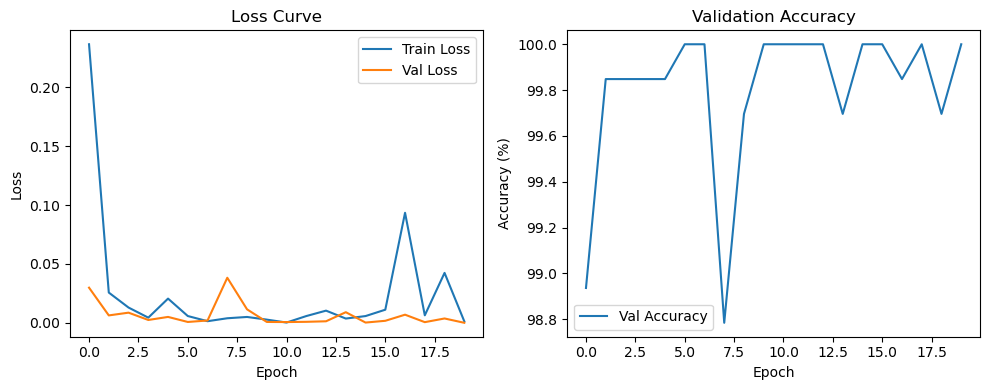

In [51]:
plt.figure(figsize=(10, 4))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

### Model Evaluation & Metrics

In [52]:
# Switch model to evaluation mode
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().view(-1, 1).to(device)

        outputs = model(images)
        preds = (outputs > 0.5).float()  # Binary threshold at 0.5

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Convert to NumPy arrays for sklearn
y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()


In [53]:
# Compute Metrics

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("Model Evaluation Metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


Model Evaluation Metrics:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


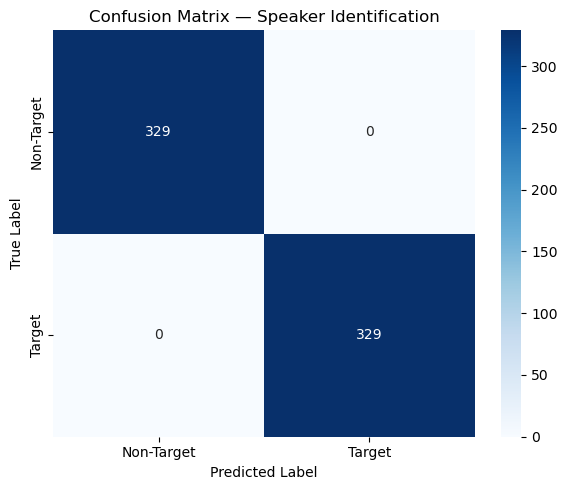

In [54]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = ["Non-Target", "Target"]

# Visualize
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix — Speaker Identification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [55]:
metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [acc, prec, rec, f1]
})
display(metrics_table)


,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0


### **Speaker Identification Transformer (Final Deployable Version)**

In [56]:
# === Define CNN globally so it can be serialized ===
class SpeakerCNN(nn.Module):
    """3-block CNN for binary speaker identification (training architecture)."""
    def __init__(self):
        super(SpeakerCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


# === Transformer class ===
class SpeakerIdentificationTransformer:
    """
    Transformer pipeline that:
      • Receives raw audio input (.flac, .wav, .mp3, etc.)
      • Converts it to a Mel-spectrogram image
      • Normalizes and transforms it for CNN input
      • Runs inference using the trained Speaker Identification CNN
    """

    def __init__(self, model_path, target_label="Rowdy Delaney"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = self._load_model(model_path)
        self.model.eval()
        self.target_label = target_label

        # === Transformations identical to training phase ===
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),     # Uniform image size
            transforms.ToTensor(),             # Convert to tensor (C×H×W)
            transforms.Normalize((0.5,), (0.5,))  # Same normalization as training
        ])

    # === 1. Load model ===
    def _load_model(self, path):
        model = SpeakerCNN().to(self.device)
        model.load_state_dict(torch.load(path, map_location=self.device))
        print("✅ CNN architecture loaded and weights restored successfully.")
        return model

    # === 2. Convert raw audio → RGB Mel-spectrogram ===
    def _audio_to_mel(self, audio_path, sr=16000):
        try:
            y, sr = librosa.load(audio_path, sr=sr)
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                               hop_length=512, n_fft=2048)
            S_dB = librosa.power_to_db(S, ref=np.max)

            fig = plt.figure(figsize=(3, 3))
            librosa.display.specshow(S_dB, sr=sr, cmap='magma')
            plt.axis('off')
            buf = io.BytesIO()
            plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
            plt.close(fig)
            buf.seek(0)
            return Image.open(buf).convert('RGB')   # RGB to match training
        except Exception as e:
            print(f"⚠️ Error processing {audio_path}: {e}")
            return None

    # === 3. Inference ===
    def predict(self, audio_path):
        img = self._audio_to_mel(audio_path)
        if img is None:
            return {"status": "error", "message": "Invalid or unreadable audio file."}

        img_tensor = self.transform(img).unsqueeze(0).to(self.device)

        with torch.no_grad():
            output = self.model(img_tensor)
            conf = float(output.item())
            label = self.target_label if conf > 0.5 else "Non-Target Speaker"

        return {
            "status": "success",
            "predicted speaker": label,
            "probability of being target speaker": round(conf, 4)
        }


In [59]:
# === Example Usage ===
pipeline = SpeakerIdentificationTransformer(
    model_path="speaker_cnn_model.pth",
    target_label="Rowdy Delaney"
)

result = pipeline.predict(r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\test data\ronickydoone_17_brand_64kb.mp3")
print(result)

✅ CNN architecture loaded and weights restored successfully.
{'status': 'success', 'predicted speaker': 'Non-Target Speaker', 'probability of being target speaker': 0.0}


In [60]:
import joblib

# Define save path ===
JOBLIB_PATH = "speaker_transformer.joblib"

# Serialize transformer (with compression for smaller file) ===
joblib.dump(pipeline, JOBLIB_PATH, compress=('zlib', 3))
print(f"✅ Transformer serialized and saved with joblib at:\n{JOBLIB_PATH}")


✅ Transformer serialized and saved with joblib at:
speaker_transformer.joblib


In [61]:
# Reload transformer to verify ===
loaded_pipeline = joblib.load(JOBLIB_PATH)
print("✅ Transformer reloaded successfully from joblib.")

✅ Transformer reloaded successfully from joblib.


In [63]:
# Run prediction using the reloaded transformer ===
TEST_AUDIO = r"C:\Users\User\OneDrive\Desktop\Clients Projects\Voice Identification (Nifemi UK)\Model Development\data\test data\ronickydoone_14_brand_64kb.mp3"

result = loaded_pipeline.predict(TEST_AUDIO)

print("Prediction Result:", result)

Prediction Result: {'status': 'success', 'predicted speaker': 'Non-Target Speaker', 'probability of being target speaker': 0.0}
